# Retention 분석 보고서

가입 완료 후 지원까지 마친 유저를 대상으로, URL 로그 기반 리텐션(재방문) 지표를 계산한다. URL 정규화·카테고리 매핑, Day N 리텐션 커브, 코호트 히트맵, 일별/롤링 리텐션을 다룬다.

- **분석 기간**: 2022-01-01 ~ 2023-12-31
- **리텐션 기준**: 첫 지원 시점으로부터 24시간 이후, 이용률 상위 30% URL을 재방문한 경우


## 1. 환경 설정

In [1]:

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import koreanize_matplotlib
import platform
import plotly.express as px
from sqlalchemy import create_engine

print("성공!")

성공!


## 2. 데이터 로드

### 2-1. DB 연결

In [2]:
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine

# 접속 정보는 코드에 두지 않는다. 저장소 루트의 .env 에서 읽어온다.
# 최초 1회: .env.example 를 .env 로 복사한 뒤 RECRUIT_DB_URL 을 채울 것.
load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.environ["RECRUIT_DB_URL"])


### 2-2. SQL 쿼리 실행

In [3]:
import pandas as pd
import numpy as np
import re

query = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)
),

step_detail_users AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1
        ON l.user_uuid = s1.user_uuid
       AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2
        ON l.user_uuid = s2.user_uuid
       AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

bookmark_users AS (
    SELECT
        d.user_uuid,
        MIN(jb.cdate) AS first_bm_time,
        COUNT(DISTINCT jb.job_uuid) AS bm_cnt
    FROM step3_done_users d
    INNER JOIN JobBookmark jb
        ON d.user_uuid = jb.user_uuid
       AND jb.cdate >= d.done_time
    GROUP BY d.user_uuid
),

first_apply_users AS (
    SELECT
        d.user_uuid,
        MIN(a.cdate) AS first_apply_time,
        COUNT(*) AS apply_total,
        COUNT(DISTINCT a.job_uuid) AS apply_job_cnt
    FROM step3_done_users d
    INNER JOIN Application a
        ON d.user_uuid = a.user_uuid
       AND a.cdate >= d.done_time
    GROUP BY d.user_uuid
),

target_logs AS (
    SELECT
        l.user_uuid,
        l.timestamp,
        l.URL,
        l.response_code,
        l.method,

        d.done_time,
        fa.first_apply_time,
        fa.apply_total,
        fa.apply_job_cnt,

        bu.first_bm_time,
        COALESCE(bu.bm_cnt, 0) AS bm_cnt

    FROM logs l
    INNER JOIN step3_done_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.done_time

    INNER JOIN first_apply_users fa
        ON l.user_uuid = fa.user_uuid

    LEFT JOIN bookmark_users bu
        ON l.user_uuid = bu.user_uuid

    WHERE l.URL IS NOT NULL
      AND TRIM(l.URL) <> ''
)

SELECT *
FROM target_logs;
"""

url_log_df = pd.read_sql(query, engine)

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df.head()


### 2-3. 시간 컬럼 타입 변환

In [4]:
time_cols = [
    "timestamp",
    "done_time",
    "first_apply_time",
    "first_bm_time"
]

for col in time_cols:
    if col in url_log_df.columns:
        url_log_df[col] = pd.to_datetime(url_log_df[col], errors="coerce")

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df.info()


## 3. URL 전처리

### 3-1. URL 경로 정제 (쿼리스트링·프래그먼트 제거)

In [5]:
url_log_df["url_path"] = (
    url_log_df["URL"]
    .astype(str)
    .str.split("?", n=1).str[0]
    .str.split("#", n=1).str[0]
    .str.strip()
    .str.strip("/")
    .str.lower()
)

### 3-2. URL 정규화 (normalize_url)

In [6]:
def normalize_url(url):
    if pd.isna(url):
        return "NULL_URL"
    
    url = str(url).strip().lower().strip("/")
    
    if url == "":
        return "NULL_URL"

    # 이상 URL
    if url.startswith(":uuid,"):
        return url

    # @user_id 계열
    if re.match(r"^@[^/]+/applications", url):
        return "@user_id/applications"
    if re.match(r"^@[^/]+/application", url):
        return "@user_id/application"
    if re.match(r"^@[^/]+/bookmark", url):
        return "@user_id/bookmark"
    if re.match(r"^@[^/]+/resume/step1", url):
        return "@user_id/resume/step1"
    if re.match(r"^@[^/]+/resume", url):
        return "@user_id/resume"
    if re.match(r"^@[^/]+/following", url):
        return "@user_id/following"
    if re.match(r"^@[^/]+$", url):
        return "@user_id"

    # signup
    if url.startswith("signup/detail"):
        return "signup/detail"
    if url.startswith("signup/step1/name"):
        return "signup/step1/name"
    if url.startswith("signup/step1/verify"):
        return "signup/step1/verify"
    if url.startswith("signup/step1"):
        return "signup/step1"
    if url.startswith("signup/step2/career"):
        return "signup/step2/career"
    if url.startswith("signup/step2/education"):
        return "signup/step2/education"
    if url.startswith("signup/step2"):
        return "signup/step2"
    if url.startswith("signup/step3/done"):
        return "signup/step3/done"
    if url.startswith("signup/step3/import"):
        return "signup/step3/import"
    if url.startswith("signup/step3/discover"):
        return "signup/step3/discover"
    if url.startswith("signup/step3"):
        return "signup/step3"
    if url.startswith("api/signup"):
        return "api/signup"

    # 공고 검색/탐색
    if url == "jobs":
        return "jobs"
    if url == "jobs/job_title":
        return "jobs/job_title"
    if url.startswith("api/jobs/job_title"):
        return "api/jobs/job_title"
    if url.startswith("suggest"):
        return "suggest"
    if url.startswith("search"):
        return "search"
    if url.startswith("api/search/jobs/job_title"):
        return "api/search/jobs/job_title"
    if url.startswith("api/search/specialty"):
        return "api/search/specialty"
    if url.startswith("api/search/companies"):
        return "api/search/companies"
    if url.startswith("api/search/people"):
        return "api/search/people"
    if url.startswith("api/recommend_specialty"):
        return "api/recommend_specialty"
    if url.startswith("api/jobs/widget/widget_templates"):
        return "api/jobs/widget/widget_templates"
    if url.startswith("api/jobs/collections/template"):
        return "api/jobs/collections/template"

    # 공고 상세 / 지원 절차
    if re.match(r"^jobs/[0-9]+/apply/step1", url):
        return "jobs/id/apply/step1"
    if re.match(r"^jobs/[0-9]+/apply/step2", url):
        return "jobs/id/apply/step2"
    if re.match(r"^jobs/[0-9]+/apply/step3", url):
        return "jobs/id/apply/step3"
    if re.match(r"^jobs/[0-9]+/apply/step4", url):
        return "jobs/id/apply/step4"
    if re.match(r"^jobs/[0-9]+/apply/complete", url):
        return "jobs/id/apply/complete"
    if re.match(r"^jobs/[0-9]+/applications", url):
        return "jobs/id/applications"
    if re.match(r"^jobs/[0-9]+/[^/]+$", url):
        return "jobs/id/id_title"
    if re.match(r"^jobs/[0-9]+$", url):
        return "jobs/id"

    if re.match(r"^api/jobs/[0-9]+/apply/step1", url):
        return "api/jobs/id/apply/step1"
    if re.match(r"^api/jobs/[0-9]+/apply/step2", url):
        return "api/jobs/id/apply/step2"
    if re.match(r"^api/jobs/[0-9]+/apply/step3", url):
        return "api/jobs/id/apply/step3"
    if re.match(r"^api/jobs/[0-9]+/apply/step4", url):
        return "api/jobs/id/apply/step4"
    if re.match(r"^api/jobs/[0-9]+/bookmark", url):
        return "api/jobs/id/bookmark"
    if re.match(r"^api/jobs/[0-9]+/other_jobs", url):
        return "api/jobs/id/other_jobs"
    if re.match(r"^api/jobs/[0-9]+/template_oneclick", url):
        return "api/jobs/id/template_oneclick"
    if re.match(r"^api/jobs/[0-9]+/stat/progress", url):
        return "api/jobs/id/stat/progress"
    if re.match(r"^api/jobs/[0-9]+", url):
        return "api/jobs/id"

    # 회사
    if url == "companies":
        return "companies"
    if re.match(r"^companies/[^/]+/jobs/job_title", url):
        return "companies/company_id/jobs/job_title"
    if re.match(r"^companies/[^/]+/jobs", url):
        return "companies/company_id/jobs"
    if re.match(r"^companies/[^/]+$", url):
        return "companies/company_id"

    if re.match(r"^api/companies/[^/]+/view", url):
        return "api/companies/id/view"
    if re.match(r"^api/companies/[^/]+/member_list", url):
        return "api/companies/id/member_list"
    if re.match(r"^api/companies/[^/]+/ad_stat/progress", url):
        return "api/companies/id/ad_stat/progress"
    if re.match(r"^api/companies/[^/]+", url):
        return "api/companies/id"

    # 프로필 / 이력서
    if re.match(r"^api/users/[^/]+/template", url):
        return "api/users/id/template"
    if re.match(r"^api/users/[^/]+/career", url):
        return "api/users/id/career"
    if re.match(r"^api/users/[^/]+/project", url):
        return "api/users/id/project"
    if re.match(r"^api/users/[^/]+/education", url):
        return "api/users/id/education"
    if re.match(r"^api/users/[^/]+/specialty", url):
        return "api/users/id/specialty"
    if re.match(r"^api/users/[^/]+/phone/verify", url):
        return "api/users/id/phone/verify"
    if re.match(r"^api/users/[^/]+", url):
        return "api/users/id"

    if url.startswith("api/people/template"):
        return "api/people/template"
    if url.startswith("api/project/form_data/media"):
        return "api/project/form_data/media"
    if url.startswith("api/references"):
        return "api/references"
    if re.match(r"^api/verify/education/[0-9]+", url):
        return "api/verify/education/id"
    if re.match(r"^api/verify/career/[0-9]+", url):
        return "api/verify/career/id"
    if re.match(r"^api/media/[0-9]+/form", url):
        return "api/media/id/form"

    # 지원 후 관리
    if url.startswith("api/apply_progress"):
        return "api/apply_progress"
    if re.match(r"^api/remove_application/[0-9]+", url):
        return "api/remove_application/id"
    if re.match(r"^api/application_thread_comment/[0-9]+", url):
        return "api/application_thread_comment/id"

    # 저장 / 오퍼 / 홈피드
    if url.startswith("api/jobs/user_filter"):
        return "api/jobs/user_filter/id"
    if re.match(r"^api/specialties/[0-9]+/follow_button", url):
        return "api/specialties/id/follow_button"
    if url.startswith("api/job_offer"):
        return "api/job_offer"
    if url.startswith("api/timeline"):
        return "api/timeline"
    if url.startswith("timeline"):
        return "timeline"
    if url.startswith("api/current_guided_action"):
        return "api/current_guided_action/id"

    # 사람 / 콘텐츠
    if url.startswith("people"):
        return "people"
    if re.match(r"^api/post/[0-9]+", url):
        return "api/post/id"
    if re.match(r"^api/page/[0-9]+/view", url):
        return "api/page/id/view"

    # 계정 / 공통
    if url.startswith("setting"):
        return "setting"
    if url.startswith("continue"):
        return "continue"
    if url.startswith("email_verify"):
        return "email_verify"
    if url.startswith("password_reset"):
        return "password_reset"
    if url.startswith("verify_phone"):
        return "verify_phone"
    if url.startswith("help"):
        return "help"

    return url

### 3-3. 정규화 URL 적용

In [7]:
url_log_df["normalized_url"] = url_log_df["url_path"].apply(normalize_url)

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df[["URL", "url_path", "normalized_url"]].head()


### 3-4. 카테고리·서브카테고리 매핑

In [8]:
# 카테고리 / 서브카테고리 매핑 참조 파일 로드
mapping_csv_path = "_cache/url_refined_category_mapping.csv"

mapping_ref = pd.read_csv(mapping_csv_path)

mapping_ref["url"] = mapping_ref["url"].astype(str).str.strip()

mapping_df = (
    mapping_ref[["url", "category", "subcategory"]]
    .drop_duplicates()
    .rename(columns={"url": "normalized_url"})
)

url_log_df = url_log_df.merge(
    mapping_df,
    on="normalized_url",
    how="left"
)

url_log_df["category"] = url_log_df["category"].fillna("99_기타/미분류")
url_log_df["subcategory"] = url_log_df["subcategory"].fillna("미분류")

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df.head()


### 3-5. URL별 집계 (category × subcategory × url)

In [9]:
refined_category = (
    url_log_df
    .groupby(["category", "subcategory", "normalized_url"], as_index=False)
    .agg(
        log_count=("user_uuid", "count"),
        user_count=("user_uuid", "nunique")
    )
    .rename(columns={"normalized_url": "url"})
)

total_logs = refined_category["log_count"].sum()
total_users = url_log_df["user_uuid"].nunique()

refined_category["log_ratio_total"] = (
    refined_category["log_count"] / total_logs * 100
).round(4)

refined_category["user_ratio_total"] = (
    refined_category["user_count"] / total_users * 100
).round(4)

refined_category = refined_category.sort_values(
    "user_count",
    ascending=False
).reset_index(drop=True)

refined_category.head(30)

### 3-6. 비정상 URL 제거

In [10]:
refined_category["url"] = refined_category["url"].astype(str).str.strip()

url_lower = refined_category["url"].astype(str).str.strip().str.lower()

# 1) :uuid, 로 시작하는 이상 URL
remove_uuid = url_lower.str.startswith(":uuid,")

# 2) 결측 / 파싱 실패 URL
remove_parsing_fail = url_lower.isin([
    "null_url",
    "none",
    "r",
    "api"
])

# 3) null / undefined 포함 URL
remove_null_or_undefined = (
    url_lower.str.contains("undefined", na=False) |
    url_lower.str.contains(r"(^|/|,)null($|/|,)", regex=True, na=False)
)

# 4) signup 들어간 URL 제거
remove_signup = url_lower.str.contains("signup", na=False)

remove_condition = (
    remove_uuid |
    remove_parsing_fail |
    remove_null_or_undefined |
    remove_signup
)

removed_url_df = refined_category[remove_condition].copy().reset_index(drop=True)
refined_category_clean = refined_category[~remove_condition].copy().reset_index(drop=True)

print("원본 URL 개수:", len(refined_category))
print("제거된 URL 개수:", len(removed_url_df))
print("남은 URL 개수:", len(refined_category_clean))

print("원본 log_count 합계:", refined_category["log_count"].sum())
print("제거된 log_count 합계:", removed_url_df["log_count"].sum())
print("남은 log_count 합계:", refined_category_clean["log_count"].sum())

refined_category_clean.head()

원본 URL 개수: 154
제거된 URL 개수: 14
남은 URL 개수: 140
원본 log_count 합계: 4497081
제거된 log_count 합계: 9459
남은 log_count 합계: 4487622


### 3-7. 상위 URL 필터링 (user_count 70% 이상)

In [11]:
user_count_threshold = refined_category_clean["user_count"].quantile(0.70)

top_url_df = refined_category_clean[
    refined_category_clean["user_count"] >= user_count_threshold
].copy()

top_url_df = top_url_df.sort_values(
    "user_count",
    ascending=False
).reset_index(drop=True)

print("user_count 70% 분위수 기준:", user_count_threshold)
print("선택된 URL 개수:", len(top_url_df))

top_url_df.head(30)

user_count 70% 분위수 기준: 2644.6
선택된 URL 개수: 42


## 4. 리텐션 정의 및 전처리

### 4-1. 리텐션 정의 기준

| 항목 | 기준 |
|------|------|
| 모수 | signup/step3/done 완료 후 첫 지원(Application)이 존재하는 유저 |
| 리텐션 인정 조건 | 첫 지원 시각으로부터 **24시간(RETENTION_GAP)** 이후 |
| 대상 URL | user_count 70% 분위수 이상인 상위 URL (top_url_df) |
| 분석 기간 | D+1 ~ D+90 |
| 관측 가능 여부 |  — D+N까지 관측 가능한 유저만 해당 day 모수에 포함 |
| 롤링 리텐션 정의 | D+N 이후 top URL에 **1회 이상** 재방문한 유저 비율 |


In [12]:
import pandas as pd

# 1. timestamp: timezone 있는 상태면 timezone 제거
url_log_df["timestamp"] = pd.to_datetime(
    url_log_df["timestamp"],
    errors="coerce"
)

if isinstance(url_log_df["timestamp"].dtype, pd.DatetimeTZDtype):
    url_log_df["timestamp"] = url_log_df["timestamp"].dt.tz_localize(None)


# 2. first_apply_time: 일반 datetime으로 변환
url_log_df["first_apply_time"] = pd.to_datetime(
    url_log_df["first_apply_time"],
    errors="coerce"
)

if isinstance(url_log_df["first_apply_time"].dtype, pd.DatetimeTZDtype):
    url_log_df["first_apply_time"] = url_log_df["first_apply_time"].dt.tz_localize(None)


# 3. 확인
# (데이터 보호: 원본 미리보기 출력 제거)
# print(url_log_df[["timestamp", "first_apply_time"]].dtypes)


### 4-2. 타임존 제거 및 datetime 정리

### 4-3. 첫 지원 이후 24시간 이후 로그 필터링

In [13]:
top_urls = set(top_url_df["url"])

# 시간값 없는 row 제거
valid_time_df = url_log_df.dropna(
    subset=["timestamp", "first_apply_time"]
).copy()

RETENTION_GAP = pd.Timedelta(hours=24) # 24시간 이후로 부터

after_first_apply_logs = valid_time_df[
    (valid_time_df["timestamp"] > valid_time_df["first_apply_time"] + RETENTION_GAP) &
    (valid_time_df["normalized_url"].isin(top_urls))
].copy()

retention_users = (
    after_first_apply_logs
    .groupby("user_uuid", as_index=False)
    .agg(
        first_retention_time=("timestamp", "min"),
        retention_log_count=("normalized_url", "count"),
        retention_url_count=("normalized_url", "nunique")
    )
)

# (데이터 보호: 원본 미리보기 출력 제거)
# retention_users


### 4-4. 리텐션 유저 집계

In [14]:
base_apply_users = (
    url_log_df[
        [
            "user_uuid",
            "done_time",
            "first_apply_time",
            "apply_total",
            "apply_job_cnt",
            "first_bm_time",
            "bm_cnt"
        ]
    ]
    .drop_duplicates(subset=["user_uuid"])
    .copy()
)

retention_result = base_apply_users.merge(
    retention_users,
    on="user_uuid",
    how="left"
)

retention_result["is_retained"] = retention_result["first_retention_time"].notna()

# (데이터 보호: 원본 미리보기 출력 제거)
# retention_result.head()


### 4-5. 리텐션 결과 테이블 생성

In [15]:
retention_summary = pd.DataFrame({
    "base_apply_users": [retention_result["user_uuid"].nunique()],
    "retained_users": [retention_result["is_retained"].sum()],
})

retention_summary["retention_rate"] = (
    retention_summary["retained_users"] / retention_summary["base_apply_users"] * 100
).round(2)

retention_summary

### 4-6. 전체 리텐션 요약

### 5-1. Day N 플래그 생성

In [16]:
# after_first_apply_logs 에서 경과 일수 계산
after_first_apply_logs["days_since_apply"] = (
    after_first_apply_logs["timestamp"] - after_first_apply_logs["first_apply_time"]
).dt.days

# 분석할 day 구간 정의
retention_days = [1, 3, 7, 14, 30, 60, 90]

# retention_result 에 day n 플래그 추가
for n in retention_days:
    day_users = (
        after_first_apply_logs[after_first_apply_logs["days_since_apply"] == n]
        ["user_uuid"].unique()
    )
    retention_result[f"retained_d{n}"] = retention_result["user_uuid"].isin(day_users)

### 5-2. Day N 리텐션 커브 계산

In [17]:
total_users = retention_result["user_uuid"].nunique()

retention_curve = pd.DataFrame({
    "day": retention_days,
    "retained_users": [
        retention_result[f"retained_d{n}"].sum() for n in retention_days
    ]
})

retention_curve["retention_rate"] = (
    retention_curve["retained_users"] / total_users * 100
).round(2)

retention_curve["total_users"] = total_users

print(retention_curve)

   day  retained_users  retention_rate  total_users
0    1            2033           49.85         4078
1    3            1595           39.11         4078
2    7            1539           37.74         4078
3   14            1106           27.12         4078
4   30             539           13.22         4078
5   60             272            6.67         4078
6   90             185            4.54         4078


### 5-3. Day N 리텐션 커브 시각화

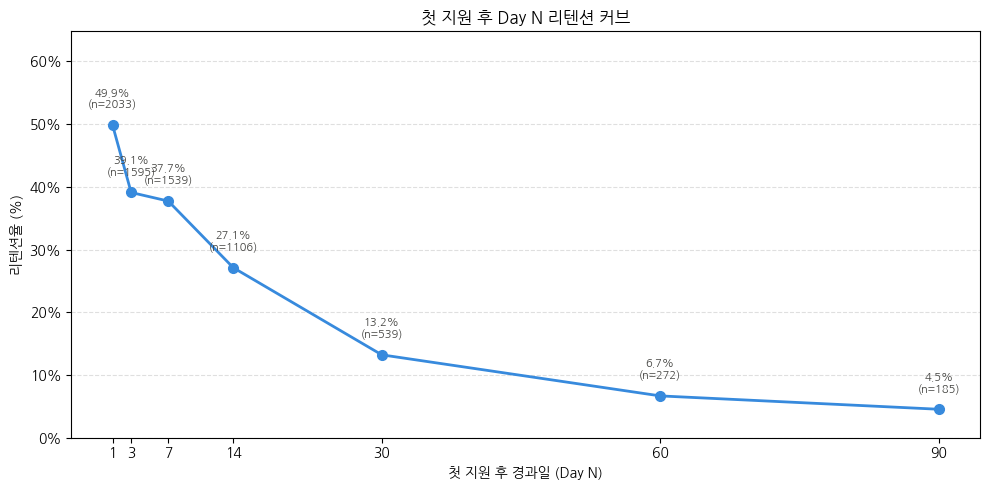

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    retention_curve["day"],
    retention_curve["retention_rate"],
    marker="o", linewidth=2, color="#378ADD", markersize=7
)

# 각 포인트에 수치 표시
for _, row in retention_curve.iterrows():
    ax.annotate(
        f"{row['retention_rate']:.1f}%\n(n={int(row['retained_users'])})",
        xy=(row["day"], row["retention_rate"]),
        xytext=(0, 12), textcoords="offset points",
        ha="center", fontsize=8, color="#444441"
    )

ax.set_xlabel("첫 지원 후 경과일 (Day N)")
ax.set_ylabel("리텐션율 (%)")
ax.set_title("첫 지원 후 Day N 리텐션 커브")
ax.set_xticks(retention_days)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, retention_curve["retention_rate"].max() * 1.3)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 5-4. 코호트 × Day N 히트맵

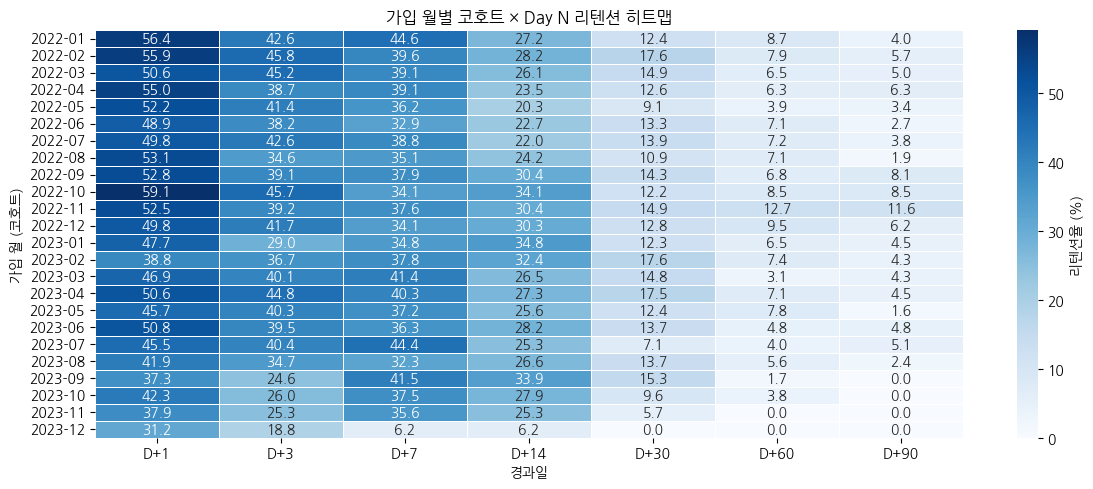

In [19]:
retention_result["cohort_month"] = pd.to_datetime(
    retention_result["done_time"]
).dt.to_period("M")

cohort_retention = retention_result.groupby("cohort_month")[[
    f"retained_d{n}" for n in retention_days
]].mean() * 100

cohort_retention.columns = [f"D+{n}" for n in retention_days]

import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cohort_retention,
    annot=True, fmt=".1f", cmap="Blues",
    linewidths=0.5, ax=ax, cbar_kws={"label": "리텐션율 (%)"}
)
ax.set_title("가입 월별 코호트 × Day N 리텐션 히트맵")
ax.set_xlabel("경과일")
ax.set_ylabel("가입 월 (코호트)")
plt.tight_layout()
plt.show()

## 6. 일별 리텐션 분석 (D+1 ~ D+90)

### 6-1. 경과 일수 및 유효 로그 필터

In [20]:
# 첫 지원 기준 경과 일수
after_first_apply_logs["days_since_apply"] = (
    after_first_apply_logs["timestamp"] - after_first_apply_logs["first_apply_time"]
).dt.days

# 음수(지원 이전 로그) 및 결측 제거
daily_logs = after_first_apply_logs[
    after_first_apply_logs["days_since_apply"] >= 1
].copy()

### 6-2. 일별 리텐션율 집계

In [21]:
total_users = retention_result["user_uuid"].nunique()

# day별 방문 유저 수 집계
daily_retention = (
    daily_logs
    .groupby("days_since_apply")["user_uuid"]
    .nunique()
    .reset_index()
    .rename(columns={"user_uuid": "retained_users"})
)

daily_retention["retention_rate"] = (
    daily_retention["retained_users"] / total_users * 100
).round(2)

# 분석 범위: D+1 ~ D+90 (필요시 조정)
daily_retention = daily_retention[
    daily_retention["days_since_apply"] <= 90
]

print(daily_retention.head(10))

   days_since_apply  retained_users  retention_rate
0                 1            2033           49.85
1                 2            1769           43.38
2                 3            1595           39.11
3                 4            1537           37.69
4                 5            1519           37.25
5                 6            1607           39.41
6                 7            1539           37.74
7                 8            1291           31.66
8                 9            1182           28.98
9                10            1114           27.32


### 6-3. 일별 리텐션 커브 시각화

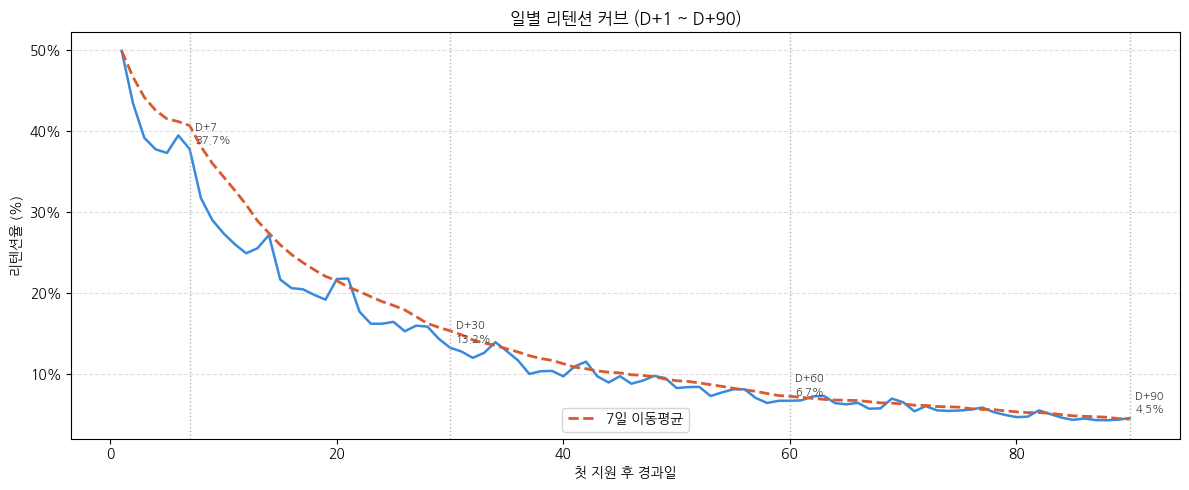

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_retention["days_since_apply"],
    daily_retention["retention_rate"],
    linewidth=1.8, color="#378ADD"
)

# 7일 이동평균선 (노이즈 완화)
daily_retention["rolling_7d"] = (
    daily_retention["retention_rate"]
    .rolling(window=7, min_periods=1)
    .mean()
)

ax.plot(
    daily_retention["days_since_apply"],
    daily_retention["rolling_7d"],
    linewidth=2, color="#D85A30", linestyle="--", label="7일 이동평균"
)

# 주요 구간 표시
for d in [7, 30, 60, 90]:
    row = daily_retention[daily_retention["days_since_apply"] == d]
    if not row.empty:
        y = row["retention_rate"].values[0]
        ax.axvline(x=d, color="#B4B2A9", linestyle=":", linewidth=1)
        ax.annotate(
            f"D+{d}\n{y:.1f}%",
            xy=(d, y), xytext=(4, 4),
            textcoords="offset points",
            fontsize=8, color="#444441"
        )

ax.set_xlabel("첫 지원 후 경과일")
ax.set_ylabel("리텐션율 (%)")
ax.set_title("일별 리텐션 커브 (D+1 ~ D+90)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 7. 롤링 리텐션 계산

### 7-1. 기본 설정 및 전처리

### 7-2. 일별 롤링 리텐션 계산

In [23]:
import pandas as pd
import numpy as np

# =========================
# 0. 기본 설정
# =========================
MAX_DAY = 90
RETENTION_GAP = pd.Timedelta(hours=24)
REQUIRE_FULL_OBSERVATION = True

# =========================
# 1. 시간 컬럼 정리
# =========================
for col in ["timestamp", "done_time", "first_apply_time", "first_bm_time"]:
    if col in url_log_df.columns:
        url_log_df[col] = pd.to_datetime(url_log_df[col], errors="coerce")

        if isinstance(url_log_df[col].dtype, pd.DatetimeTZDtype):
            url_log_df[col] = url_log_df[col].dt.tz_localize(None)

# =========================
# 2. 리텐션 기준 URL 필터
# =========================
top_urls = set(top_url_df["url"])

retention_log_base = (
    url_log_df
    .dropna(subset=["user_uuid", "timestamp", "first_apply_time"])
    .copy()
)

retention_log_base = retention_log_base[
    retention_log_base["normalized_url"].isin(top_urls)
].copy()

# 첫 지원 후 24시간 이후 로그만 리텐션 후보로 사용
retention_log_base = retention_log_base[
    retention_log_base["timestamp"] >= retention_log_base["first_apply_time"] + RETENTION_GAP
].copy()

# =========================
# 3. 모수: 첫 지원 유저
# =========================
base_users = (
    url_log_df[
        [
            "user_uuid",
            "done_time",
            "first_apply_time",
            "apply_total",
            "apply_job_cnt",
            "first_bm_time",
            "bm_cnt"
        ]
    ]
    .dropna(subset=["user_uuid", "first_apply_time"])
    .drop_duplicates(subset=["user_uuid"])
    .copy()
)

# today 대신 data_end 기준으로 관측 가능 여부 판단
data_end = retention_log_base["timestamp"].max()

# =========================
# 4. 일별 롤링 리텐션 계산
# =========================
rolling_retention_results = []

for day in range(1, MAX_DAY + 1):

    # D+n 이후를 관측할 수 있는 유저만 모수로 사용
    if REQUIRE_FULL_OBSERVATION:
        eligible_users = base_users[
            base_users["first_apply_time"] + pd.Timedelta(days=day) <= data_end
        ].copy()
    else:
        eligible_users = base_users.copy()

    temp_logs = retention_log_base[
        retention_log_base["user_uuid"].isin(eligible_users["user_uuid"])
    ].copy()

    # 롤링 리텐션: D+n 이후 한 번이라도 활동했는가
    start_time = temp_logs["first_apply_time"] + pd.Timedelta(days=day)

    retained_logs = temp_logs[
        temp_logs["timestamp"] >= start_time
    ].copy()

    base_cnt = eligible_users["user_uuid"].nunique()
    retained_cnt = retained_logs["user_uuid"].nunique()

    rolling_retention_results.append({
        "day": day,
        "day_label": f"D+{day}",
        "base_apply_users": base_cnt,
        "retained_users": retained_cnt,
        "rolling_retention_rate": round(retained_cnt / base_cnt * 100, 2) if base_cnt > 0 else np.nan
    })

daily_rolling_retention = pd.DataFrame(rolling_retention_results)

print(daily_rolling_retention)

    day day_label  base_apply_users  retained_users  rolling_retention_rate
0     1       D+1              4076            3792                   93.03
1     2       D+2              4075            3736                   91.68
2     3       D+3              4071            3694                   90.74
3     4       D+4              4065            3664                   90.14
4     5       D+5              4064            3627                   89.25
..  ...       ...               ...             ...                     ...
85   86      D+86              3679            2107                   57.27
86   87      D+87              3674            2095                   57.02
87   88      D+88              3671            2080                   56.66
88   89      D+89              3662            2072                   56.58
89   90      D+90              3660            2063                   56.37

[90 rows x 5 columns]


### 7-3. 결과 확인

In [24]:
daily_rolling_retention.head(30)

### 7-4. 롤링 리텐션 커브 시각화

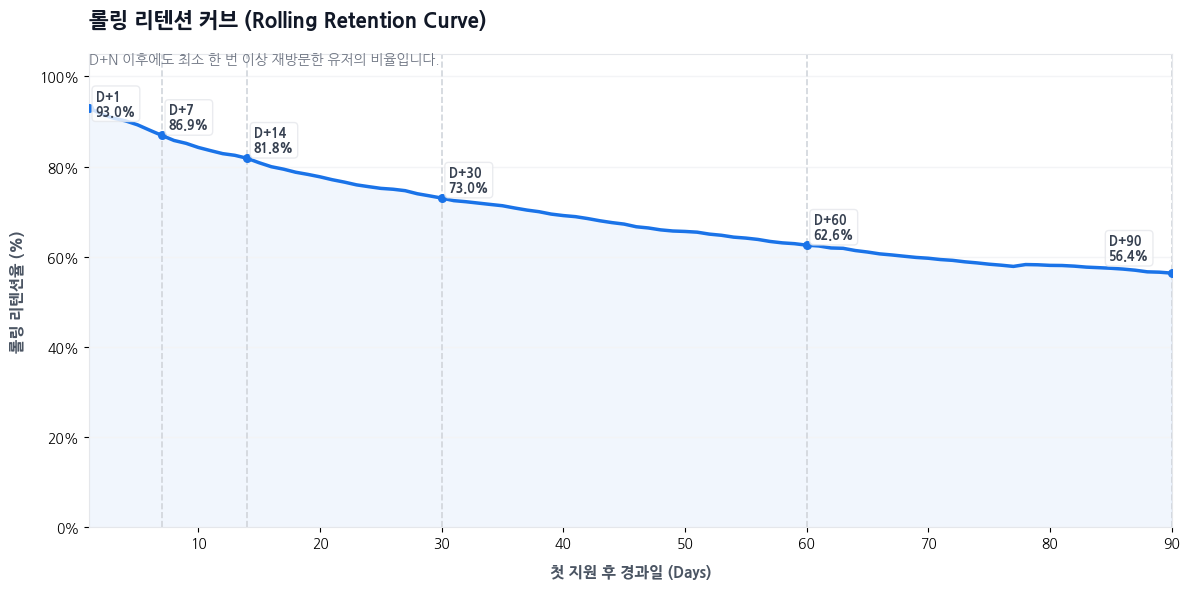

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# 1. 메인 커브 및 영역 채우기
ax.plot(
    daily_rolling_retention["day"],
    daily_rolling_retention["rolling_retention_rate"],
    linewidth=2.5, color="#1A73E8", label="Rolling Retention"
)
ax.fill_between(
    daily_rolling_retention["day"],
    daily_rolling_retention["rolling_retention_rate"],
    alpha=0.06, color="#1A73E8"
)

# 2. 주요 마일스톤 강조 (D+1, D+7, D+14, D+30, D+60, D+90)
text_offsets = {1: (5, -5), 7: (5, 5), 14: (5, 5), 30: (5, 5), 60: (5, 5), 90: (-45, 10)}

for d in [1, 7, 14, 30, 60, 90]:
    if d in daily_rolling_retention["day"].values:
        row = daily_rolling_retention[daily_rolling_retention["day"] == d].iloc[0]
        rate = row['rolling_retention_rate']
        
        # 세로 절취선
        ax.axvline(x=d, color="#D1D5DB", linestyle="--", linewidth=1.2)
        
        # 데이터 포인트에 작은 점 표시
        ax.scatter(d, rate, color="#1A73E8", s=30, zorder=3)
        
        # 주석 문구 설정 (글씨 뒤에 흰색 말풍선을 달아 가독성 확보)
        ax.annotate(
            f"D+{d}\n{rate:.1f}%",
            xy=(d, rate),
            xytext=text_offsets.get(d, (5, 5)), 
            textcoords="offset points",
            fontsize=9, 
            fontweight="bold",
            color="#374151",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#E5E7EB", lw=1, alpha=0.8)
        )

# 3. 축 및 레이블 스타일링
ax.set_xlabel("첫 지원 후 경과일 (Days)", fontsize=11, fontweight="bold", labelpad=10, color="#4B5563")
ax.set_ylabel("롤링 리텐션율 (%)", fontsize=11, fontweight="bold", labelpad=10, color="#4B5563")

# 타이틀 왼쪽 정렬 및 서브타이틀
ax.set_title("롤링 리텐션 커브 (Rolling Retention Curve)", fontsize=15, fontweight="bold", pad=20, loc="left", color="#111827")
ax.text(1, 103, "D+N 이후에도 최소 한 번 이상 재방문한 유저의 비율입니다.", fontsize=10, color="#6B7280")

# 축 범위 및 포맷 변경 (30일 기준으로 xlim 조정)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(1, 90)
ax.set_ylim(0, 105) # 상단 말풍선이 잘리지 않도록 여유 제공

# 4. 그리드 및 외곽 테두리 정돈
ax.grid(visible=True, axis="y", linestyle="-", color="#F3F4F6", linewidth=1)
ax.grid(visible=False, axis="x") # 세로선은 axvline과 겹치므로 깔끔하게 제거

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_color("#E5E7EB")

plt.tight_layout()
plt.show()

## 8. 요약

이 노트북에서는 Day N 리텐션 커브, 코호트 × Day N 히트맵, 일별/롤링 리텐션 곡선을 계산했다. 각 지표에 대한 구체적인 수치 해석과 종합 인사이트는 `05_CoreUser_Report.ipynb`의 "6. Retention 분석" 절에서 다룬다.
